### 📊 AED para explorar o IAA (Autoavaliação)

**Base:** `df_base_2.parquet` — atualização gerada no Notebook `03_AED_IEG.ipynb`.

**❓Pergunta chave:**
- As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?

**Sub-perguntas:**
- Qual a distribuição do IAA por ano?
- Existe correlação entre IAA e IDA? Os alunos se avaliam de forma realista em relação ao desempenho?
- Existe correlação entre IAA e IEG? Os alunos se avaliam de forma realista em relação ao engajamento?
- Quem se superestima e quem se subestima?
- Existem alunos que se acham bons mas são fracos em ambos (IDA e IEG)?

### ⚙️ Import e Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_parquet('../../data/db/01_silver_processed/df_base_2.parquet')

print(f'df_base: {df.shape[0]} linhas | {df.shape[1]} colunas')

df_base: 3030 linhas | 31 colunas


### Distribuição IAA por Ano

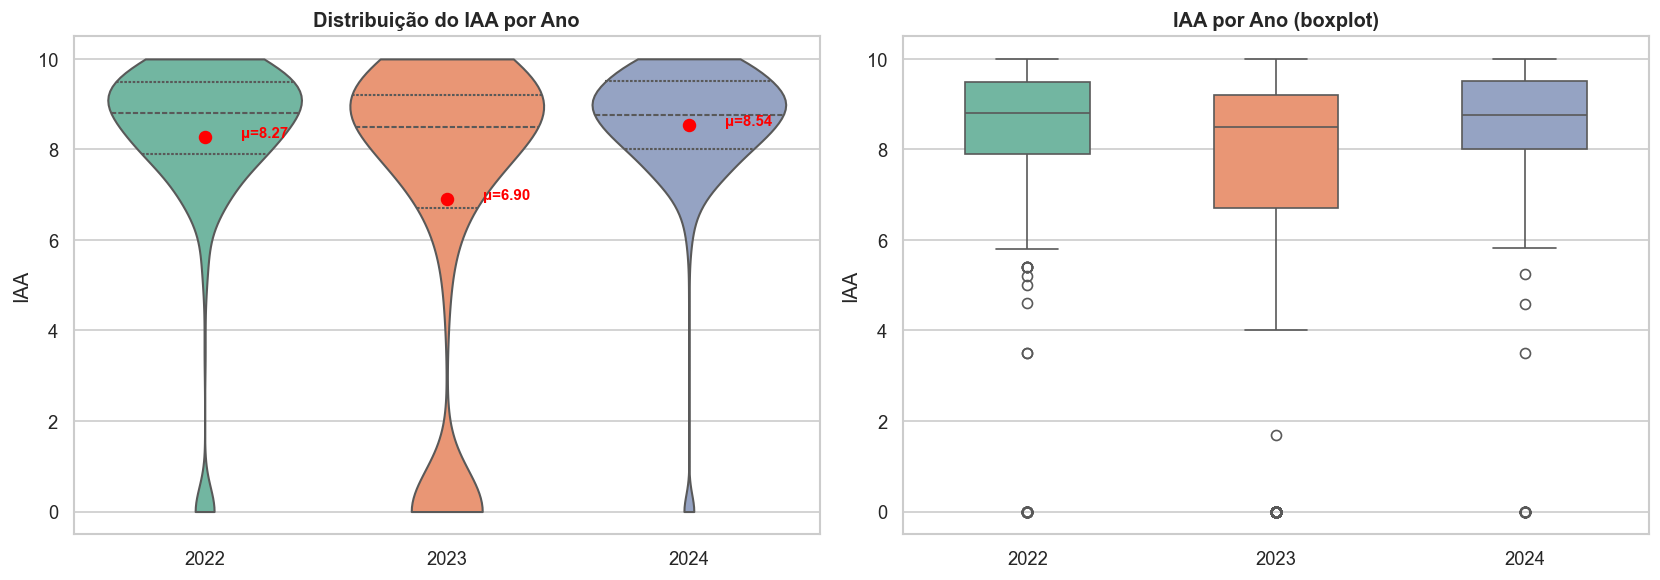

=== IAA — Estatísticas por ano ===
       count  mean   std  min  25%   50%  75%   max
ano                                                
2022   860.0  8.27  2.06  0.0  7.9  8.80  9.5  10.0
2023   951.0  6.90  3.59  0.0  6.7  8.50  9.2  10.0
2024  1054.0  8.54  1.49  0.0  8.0  8.75  9.5  10.0


In [2]:
# Distribuição do IAA por ano
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dados_violin = df[df['IAA'].notna()].copy()
dados_violin['ano'] = dados_violin['ano'].astype(str)

sns.violinplot(data=dados_violin, x='ano', y='IAA', ax=axes[0],
               palette='Set2', inner='quartile', cut=0)

medias = dados_violin.groupby('ano')['IAA'].mean()
for i, (ano, media) in enumerate(medias.items()):
    axes[0].scatter(i, media, color='red', s=50, zorder=5)
    axes[0].text(i + 0.15, media, f'μ={media:.2f}', fontsize=9, fontweight='bold', color='red')

axes[0].set_title('Distribuição do IAA por Ano', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('IAA')

sns.boxplot(data=dados_violin, x='ano', y='IAA', ax=axes[1], palette='Set2', width=0.5)
axes[1].set_title('IAA por Ano (boxplot)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('IAA')

plt.tight_layout()
plt.show()

print('=== IAA — Estatísticas por ano ===')
print(df.groupby('ano')['IAA'].describe().round(2).to_string())

##### 💡 Insights — Distribuição do IAA

- O IAA é alto nos 3 anos: medianas acima de 8.5
  - Ou seja, *os alunos tendem a se avaliar positivamente*
- 2023 é o ano com maior dispersão (std=3.59) e menor média (6.90), apesar da mediana similar (8.50)
  - A queda da média de 2023 é puxada por um grupo de alunos com IAA muito baixo
  - possível efeito da escala diferente para fases 0–2 vs 3-8?

### IAA vs IDA

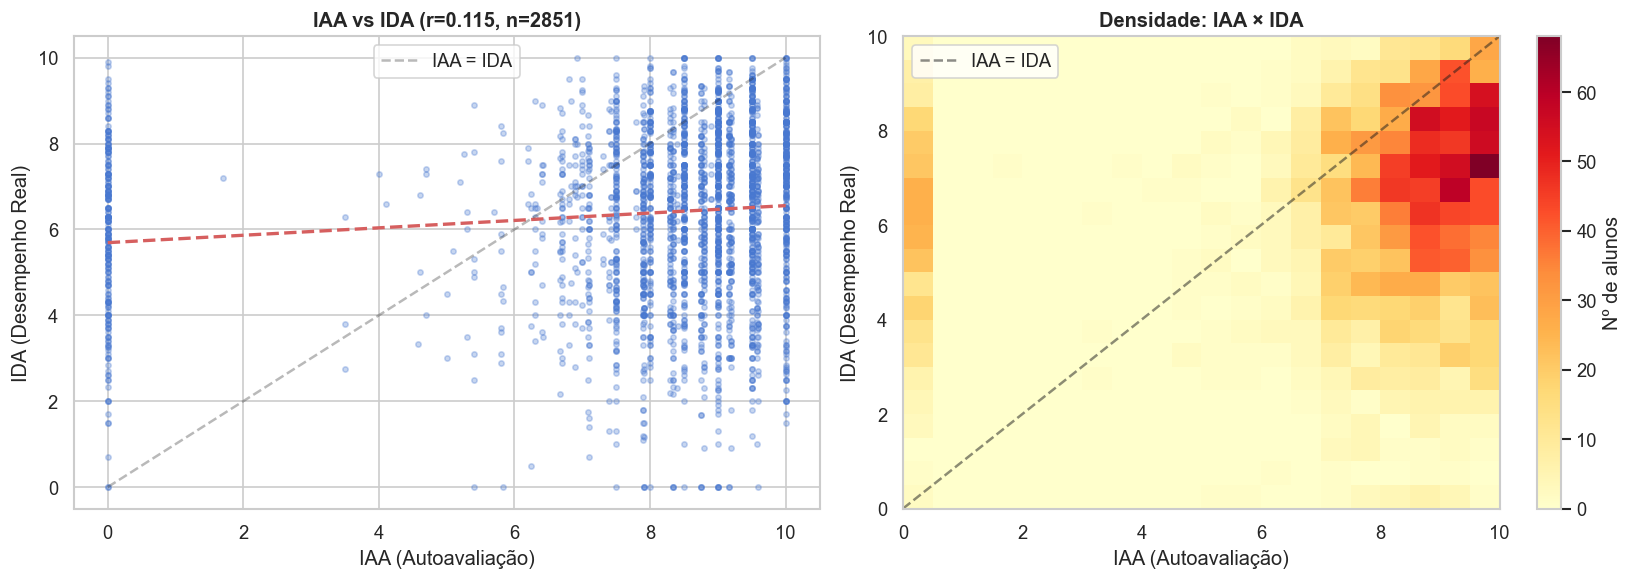

In [3]:
# IAA vs IDA — o aluno se avalia de forma coerente com seu desempenho?
df_coe = df[df['IAA'].notna() & df['IDA'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter com regressão
axes[0].scatter(df_coe['IAA'], df_coe['IDA'], alpha=0.3, s=10)
corr_iaa_ida = df_coe['IAA'].corr(df_coe['IDA'])
z = np.polyfit(df_coe['IAA'], df_coe['IDA'], 1)
p = np.poly1d(z)
x_range = np.linspace(df_coe['IAA'].min(), df_coe['IAA'].max(), 100)
axes[0].plot(x_range, p(x_range), 'r--', linewidth=2)
# Linha de referência: se IAA == IDA perfeitamente
axes[0].plot([0, 10], [0, 10], 'k--', alpha=0.3, label='IAA = IDA')
axes[0].set_title(f'IAA vs IDA (r={corr_iaa_ida:.3f}, n={len(df_coe)})', fontweight='bold')
axes[0].set_xlabel('IAA (Autoavaliação)')
axes[0].set_ylabel('IDA (Desempenho Real)')
axes[0].legend()

# Heatmap de densidade
h = axes[1].hist2d(df_coe['IAA'], df_coe['IDA'], bins=20, cmap='YlOrRd')
plt.colorbar(h[3], ax=axes[1], label='Nº de alunos')
axes[1].plot([0, 10], [0, 10], 'k--', alpha=0.5, label='IAA = IDA')
axes[1].set_title('Densidade: IAA × IDA', fontweight='bold')
axes[1].set_xlabel('IAA (Autoavaliação)')
axes[1].set_ylabel('IDA (Desempenho Real)')
axes[1].legend()

plt.tight_layout()
plt.show()

##### 💡 Insights — IAA vs IDA

- Correlação muito fraca (0.115): a autoavaliação **não reflete o desempenho real**
- Os alunos tendem a se avaliar positivamente (independente da nota)
  - IAA concentrado em 8-10 enquanto IDA varia de 0 a 10
  - 
- O heatmap mostra concentração em IAA alto + IDA alto
  - mas faixa significativa de IAA alto + IDA médio-baixo (superestimação)
  - ⚠️ Parece que o IAA está medindo mais **autoestima/confiança** do que real percepção de desempenho
  - 
- 💡 **Para o modelo de ML:** IAA provavelmente não é bom preditor de desempenho, mas a **diferença IAA - IDA** (gap) pode ser informativa

### Classificar coerência (superestima / subestima / coerente)

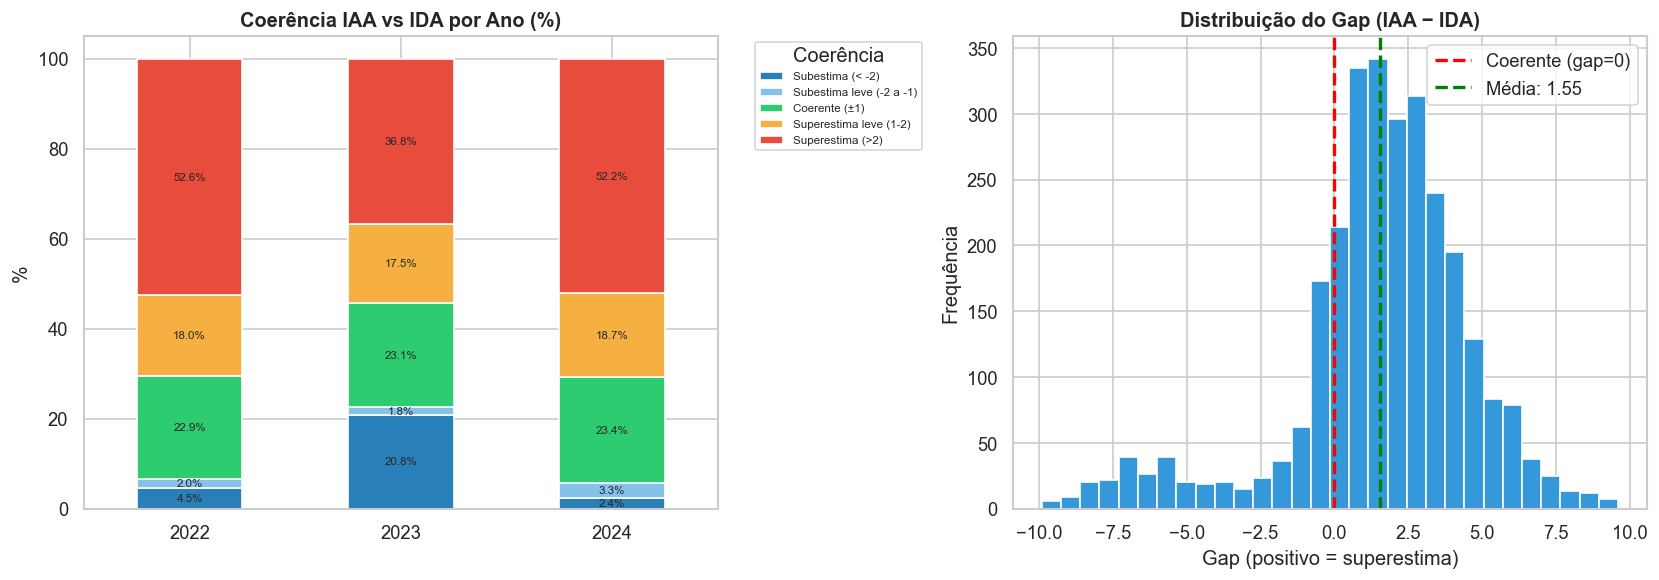

=== Coerência por ano (%) ===
coerencia  Subestima (< -2)  Subestima leve (-2 a -1)  Coerente (±1)  Superestima leve (1-2)  Superestima (>2)
ano                                                                                                           
2022                    4.5                       2.0           22.9                    18.0              52.6
2023                   20.8                       1.8           23.1                    17.5              36.8
2024                    2.4                       3.3           23.4                    18.7              52.2

=== Gap (IAA - IDA) — Estatísticas ===
  Média: 1.55
  Mediana: 1.80
  Desvio: 3.08


In [4]:
# Classificar: o aluno se superestima, subestima ou é coerente?
# Diferença = IAA - IDA: positivo = se superestima, negativo = se subestima
df_coe['gap'] = df_coe['IAA'] - df_coe['IDA']

def classificar_coerencia(gap):
    if gap > 2: return 'Superestima (>2)'
    if gap > 1: return 'Superestima leve (1-2)'
    if gap < -2: return 'Subestima (< -2)'
    if gap < -1: return 'Subestima leve (-2 a -1)'
    return 'Coerente (±1)'

df_coe['coerencia'] = df_coe['gap'].apply(classificar_coerencia)

ordem = ['Subestima (< -2)', 'Subestima leve (-2 a -1)', 'Coerente (±1)',
         'Superestima leve (1-2)', 'Superestima (>2)']
cores = {'Subestima (< -2)': '#2980b9', 'Subestima leve (-2 a -1)': '#85c1e9',
         'Coerente (±1)': '#2ecc71',
         'Superestima leve (1-2)': '#f5b041', 'Superestima (>2)': '#e74c3c'}

# Por ano
ct = pd.crosstab(df_coe['ano'], df_coe['coerencia'])[ordem]
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras empilhadas
ct_pct.plot(kind='bar', stacked=True, ax=axes[0],
            color=[cores[c] for c in ordem])
axes[0].set_title('Coerência IAA vs IDA por Ano (%)', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('%')
axes[0].legend(title='Coerência', fontsize=7, bbox_to_anchor=(1.05, 1))
axes[0].tick_params(axis='x', rotation=0)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', label_type='center', fontsize=7)

# Histograma do gap
axes[1].hist(df_coe['gap'], bins=30, color='#3498db', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Coerente (gap=0)')
axes[1].axvline(df_coe['gap'].mean(), color='green', linestyle='--', linewidth=2,
                label=f'Média: {df_coe["gap"].mean():.2f}')
axes[1].set_title('Distribuição do Gap (IAA − IDA)', fontweight='bold')
axes[1].set_xlabel('Gap (positivo = superestima)')
axes[1].set_ylabel('Frequência')
axes[1].legend()

plt.tight_layout()
plt.show()

print('=== Coerência por ano (%) ===')
print(ct_pct.round(1).to_string())
print(f'\n=== Gap (IAA - IDA) — Estatísticas ===')
print(f'  Média: {df_coe["gap"].mean():.2f}')
print(f'  Mediana: {df_coe["gap"].median():.2f}')
print(f'  Desvio: {df_coe["gap"].std():.2f}')

##### 💡 Insights — Coerência IAA vs IDA

- **~70% dos alunos se superestimam** (gap IAA-IDA > 1) — padrão consistente em 2022 e 2024
- Gap médio = +1.55 pontos
  - os alunos se dão, na média, 1.5 pontos acima do desempenho real
- Apenas ~23% são coerentes (gap dentro de ±1)
- 2023 tem 20.8% de subestimação
  - provavelmente ligada à escala diferente do IAA por fase? tenho que validar isso

=== Gap médio (IAA - IDA) por nível ===
       gap_medio  gap_mediano    n
nivel                             
1           1.56         1.75  550
2           1.50         1.90  539
3           2.22         2.70  491
4           1.65         2.00  285
5           1.57         1.83  225
6           0.24         1.46   76
7           2.05         1.83   68
ALFA        1.11         1.30  617


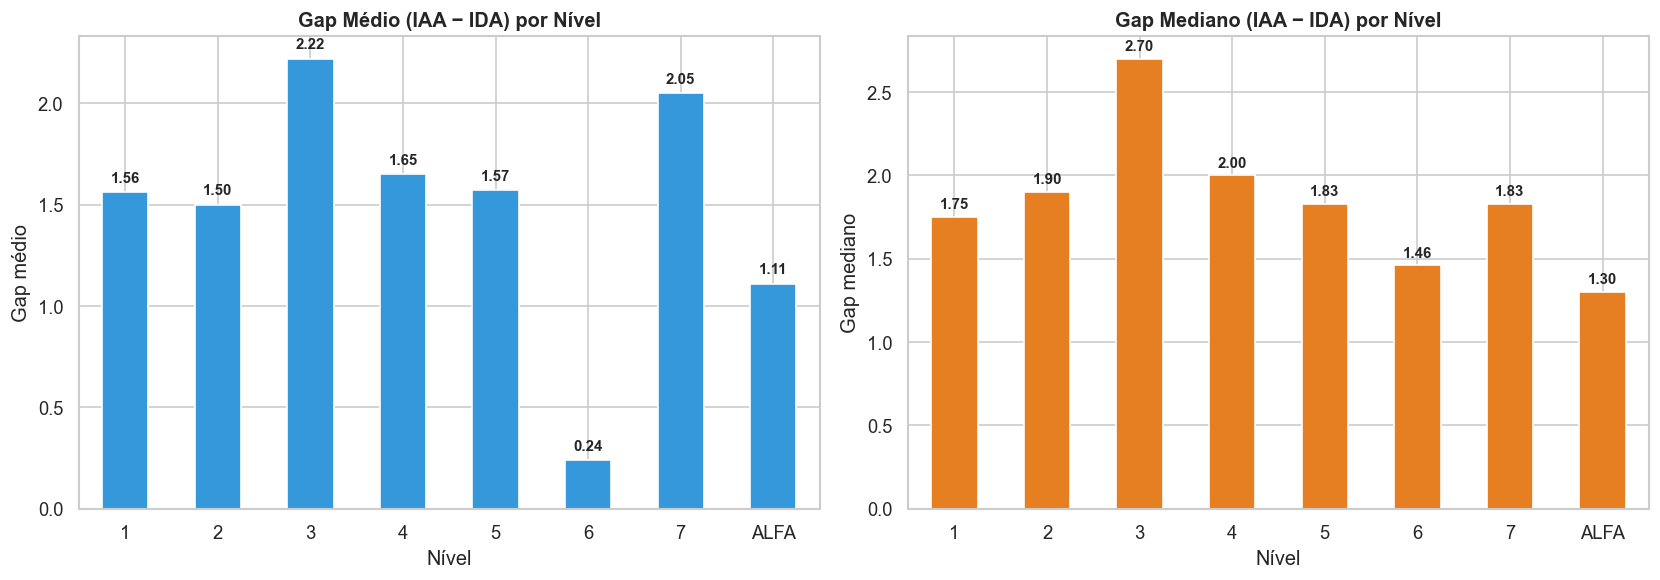

In [5]:
# Gap médio e mediano por nível
df_coe_nivel = df_coe.copy()

gap_por_nivel = df_coe_nivel.groupby('nivel')['gap'].agg(['mean', 'median', 'count']).round(2)
gap_por_nivel.columns = ['gap_medio', 'gap_mediano', 'n']

print('=== Gap médio (IAA - IDA) por nível ===')
print(gap_por_nivel.sort_index().to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gap médio
gap_por_nivel['gap_medio'].plot(kind='bar', ax=axes[0], color='#3498db')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Gap Médio (IAA − IDA) por Nível', fontweight='bold')
axes[0].set_xlabel('Nível')
axes[0].set_ylabel('Gap médio')
axes[0].tick_params(axis='x', rotation=0)

for i, (nivel, row) in enumerate(gap_por_nivel.iterrows()):
    axes[0].text(i, row['gap_medio'] + 0.05, f'{row["gap_medio"]:.2f}', ha='center', fontsize=9, fontweight='bold')

# Gap mediano
gap_por_nivel['gap_mediano'].plot(kind='bar', ax=axes[1], color='#e67e22')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Gap Mediano (IAA − IDA) por Nível', fontweight='bold')
axes[1].set_xlabel('Nível')
axes[1].set_ylabel('Gap mediano')
axes[1].tick_params(axis='x', rotation=0)

for i, (nivel, row) in enumerate(gap_por_nivel.iterrows()):
    axes[1].text(i, row['gap_mediano'] + 0.05, f'{row["gap_mediano"]:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

##### 💡 Insights — Gap por Nível

- **Nível 3 é o pior em dois pilares:**
  - pior IDA (gargalo acadêmico)
  - E maior superestimação (gap médio=2.22, mediano=2.70)
- A mediana ser maior que a média no nível 3 indica que **a maioria** dos alunos se superestima fortemente
  - não são outliers puxando o número
- O aluno típico do nível 3 se dá 2.7 pontos acima do desempenho real
-
- **Nível 6** tem a menor média (0.24), porém a mediana é 1.46
  - alguns alunos se subestimam bastante puxando a média para baixo, mas o aluno típico ainda se superestima levemente
  - Todos os níveis superestimam (gap sempre positivo em média e mediana), mas a intensidade diminui com a maturidade
  -   
- 💡 **Para a ONG:** 
  - o nível 3 precisa de atenção especial
    - além do reforço acadêmico, os alunos precisam de feedback realista sobre seu desempenho para calibrar expectativas

### IAA vs IEG

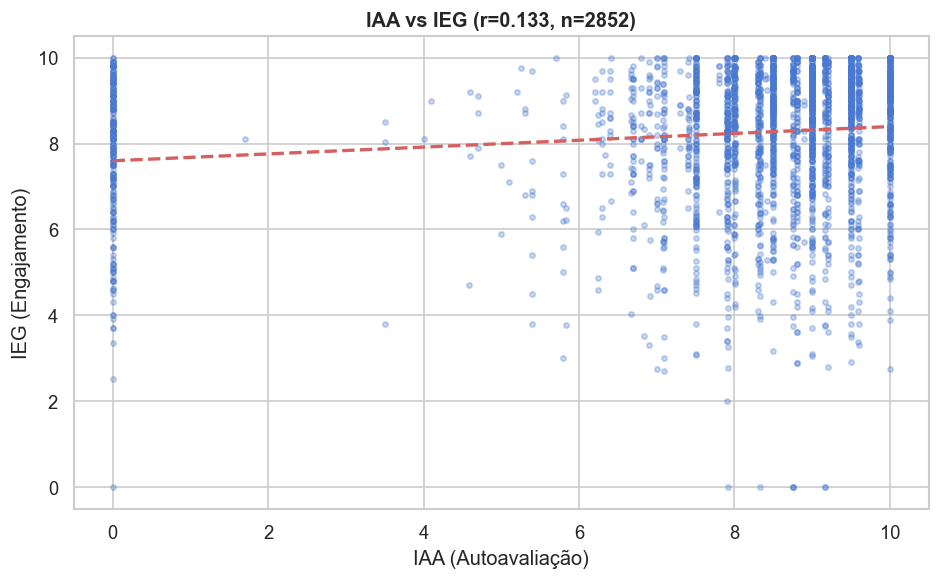

=== Correlações do IAA ===
  IAA × IDA: r=0.115
  IAA × IEG: r=0.133


In [6]:
# IAA vs IEG — autopercepção é coerente com engajamento?
df_coe_ieg = df[df['IAA'].notna() & df['IEG'].notna()].copy()

corr_iaa_ieg = df_coe_ieg['IAA'].corr(df_coe_ieg['IEG'])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_coe_ieg['IAA'], df_coe_ieg['IEG'], alpha=0.3, s=10)
z = np.polyfit(df_coe_ieg['IAA'], df_coe_ieg['IEG'], 1)
p = np.poly1d(z)
x_range = np.linspace(df_coe_ieg['IAA'].min(), df_coe_ieg['IAA'].max(), 100)
ax.plot(x_range, p(x_range), 'r--', linewidth=2)
ax.set_title(f'IAA vs IEG (r={corr_iaa_ieg:.3f}, n={len(df_coe_ieg)})', fontweight='bold')
ax.set_xlabel('IAA (Autoavaliação)')
ax.set_ylabel('IEG (Engajamento)')

plt.tight_layout()
plt.show()

print(f'=== Correlações do IAA ===')
print(f'  IAA × IDA: r={corr_iaa_ida:.3f}')
print(f'  IAA × IEG: r={corr_iaa_ieg:.3f}')

##### 💡 Insights — IAA vs IEG

- Correlação muito fraca (0.133)
  - a autoavaliação também **não reflete o engajamento real**
- As duas correlações do IAA são igualmente fracas:
  - 0.115 (IDA)
  - 0.133 (IEG)
- O IAA mede uma dimensão própria — provavelmente **autoestima/confiança** — que é independente do desempenho e do engajamento


**Resposta à pergunta 4:** Não, as percepções dos alunos sobre si mesmos (IAA) **não são coerentes** com seu desempenho real (IDA) nem com seu engajamento (IEG). ~70% se superestimam, com gap médio de +1.55 pontos

### IAA × IDA × IEG

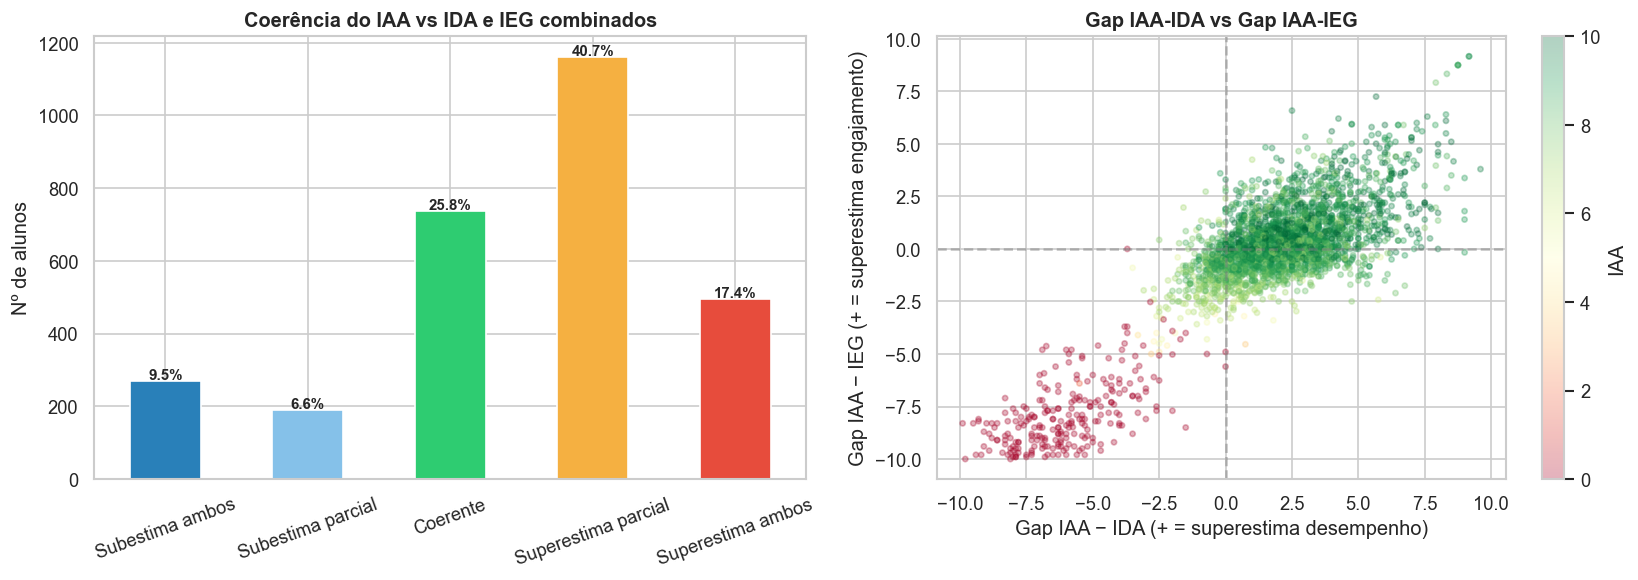

=== Coerência combinada (IAA vs IDA e IEG) ===
  Subestima ambos          :  270 (9.5%)
  Subestima parcial        :  189 (6.6%)
  Coerente                 :  736 (25.8%)
  Superestima parcial      : 1160 (40.7%)
  Superestima ambos        :  496 (17.4%)

=== Perfil dos que superestimam ambos (496 alunos) ===
  IAA médio: 9.06
  IDA médio: 4.72
  IEG médio: 6.08
  INDE médio: 6.40
  Nível mais comum: 3


In [7]:
# Análise combinada: IAA vs IDA vs IEG
df_trio = df[df['IAA'].notna() & df['IDA'].notna() & df['IEG'].notna()].copy()

# Gap do IAA em relação a cada indicador
df_trio['gap_ida'] = df_trio['IAA'] - df_trio['IDA']
df_trio['gap_ieg'] = df_trio['IAA'] - df_trio['IEG']

# Classificar coerência combinada
def coerencia_combinada(row):
    superestima_ida = row['gap_ida'] > 1.5
    superestima_ieg = row['gap_ieg'] > 1.5
    subestima_ida = row['gap_ida'] < -1.5
    subestima_ieg = row['gap_ieg'] < -1.5

    if superestima_ida and superestima_ieg:
        return 'Superestima ambos'
    if subestima_ida and subestima_ieg:
        return 'Subestima ambos'
    if superestima_ida or superestima_ieg:
        return 'Superestima parcial'
    if subestima_ida or subestima_ieg:
        return 'Subestima parcial'
    return 'Coerente'

df_trio['coerencia_geral'] = df_trio.apply(coerencia_combinada, axis=1)

# Resumo
ordem_comb = ['Subestima ambos', 'Subestima parcial', 'Coerente', 'Superestima parcial', 'Superestima ambos']
ct_comb = df_trio['coerencia_geral'].value_counts().reindex(ordem_comb).fillna(0).astype(int)
ct_comb_pct = (ct_comb / len(df_trio) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras de coerência combinada
cores_comb = {'Subestima ambos': '#2980b9', 'Subestima parcial': '#85c1e9',
              'Coerente': '#2ecc71',
              'Superestima parcial': '#f5b041', 'Superestima ambos': '#e74c3c'}

ct_comb.plot(kind='bar', ax=axes[0], color=[cores_comb[c] for c in ordem_comb])
axes[0].set_title('Coerência do IAA vs IDA e IEG combinados', fontweight='bold')
axes[0].set_ylabel('Nº de alunos')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)

for i, (cat, n) in enumerate(ct_comb.items()):
    axes[0].text(i, n + 5, f'{ct_comb_pct[cat]}%', ha='center', fontweight='bold', fontsize=9)

# Scatter: gap_ida vs gap_ieg (cada ponto é um aluno)
scatter = axes[1].scatter(df_trio['gap_ida'], df_trio['gap_ieg'], alpha=0.3, s=10,
                          c=df_trio['IAA'], cmap='RdYlGn')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Gap IAA-IDA vs Gap IAA-IEG', fontweight='bold')
axes[1].set_xlabel('Gap IAA − IDA (+ = superestima desempenho)')
axes[1].set_ylabel('Gap IAA − IEG (+ = superestima engajamento)')
plt.colorbar(scatter, ax=axes[1], label='IAA')

plt.tight_layout()
plt.show()

print('=== Coerência combinada (IAA vs IDA e IEG) ===')
for cat in ordem_comb:
    print(f'  {cat:25}: {ct_comb[cat]:4d} ({ct_comb_pct[cat]}%)')

# Perfil dos que superestimam ambos
super_ambos = df_trio[df_trio['coerencia_geral'] == 'Superestima ambos']
if len(super_ambos) > 0:
    print(f'\n=== Perfil dos que superestimam ambos ({len(super_ambos)} alunos) ===')
    print(f'  IAA médio: {super_ambos["IAA"].mean():.2f}')
    print(f'  IDA médio: {super_ambos["IDA"].mean():.2f}')
    print(f'  IEG médio: {super_ambos["IEG"].mean():.2f}')
    print(f'  INDE médio: {super_ambos["INDE"].mean():.2f}')
    print(f'  Nível mais comum: {super_ambos["nivel"].mode().values[0]}')

##### 💡 Insights — Visão Combinada IAA × IDA × IEG

- 58.1% dos alunos superestimam seu desempenho e/ou engajamento; apenas 25.8% são coerentes
- Os 496 alunos que **superestimam ambos** (17.4%) têm o perfil mais crítico: se dão nota 9.06 mas tiram 4.72 no IDA e 6.08 no IEG
- O **nível 3** é novamente o mais representado nesse grupo — reforçando que é o nível que mais precisa de intervenção
- Os alunos superestimam mais o desempenho (gap IDA maior) do que o engajamento (gap IEG menor)
- Os que subestimam ambos (9.5%) têm IAA baixo — podem estar com autoestima comprometida, merecendo atenção psicossocial

### Validar as diferentes escalas do IAA

=== IAA médio por nível e ano ===
ano    2022  2023  2024
nivel                  
1      8.64  7.20  8.81
2      8.41  6.62  8.20
3      7.49  6.38  8.48
4      7.71  6.95  8.11
5      8.11  6.44  8.30
6      6.51  6.38  8.65
7      7.01  6.51  8.86
ALFA   8.98  7.46  8.99

=== Contagem por nível e ano ===
ano    2022  2023  2024
nivel                  
1       192   173   185
2       155   200   185
3       148   132   211
4        76    94   115
5        60    65   100
6        18    33    25
7        21    23    37
ALFA    190   231   196

=== IAA por grupo de fase e ano ===
                 mean   std  count
ano  grupo_fase                   
2022 Fases 0-2   8.70  1.52    537
     Fases 3-8   7.57  2.59    323
2023 Fases 0-2   7.11  3.61    604
     Fases 3-8   6.55  3.54    347
2024 Fases 0-2   8.67  1.42    566
     Fases 3-8   8.39  1.56    488


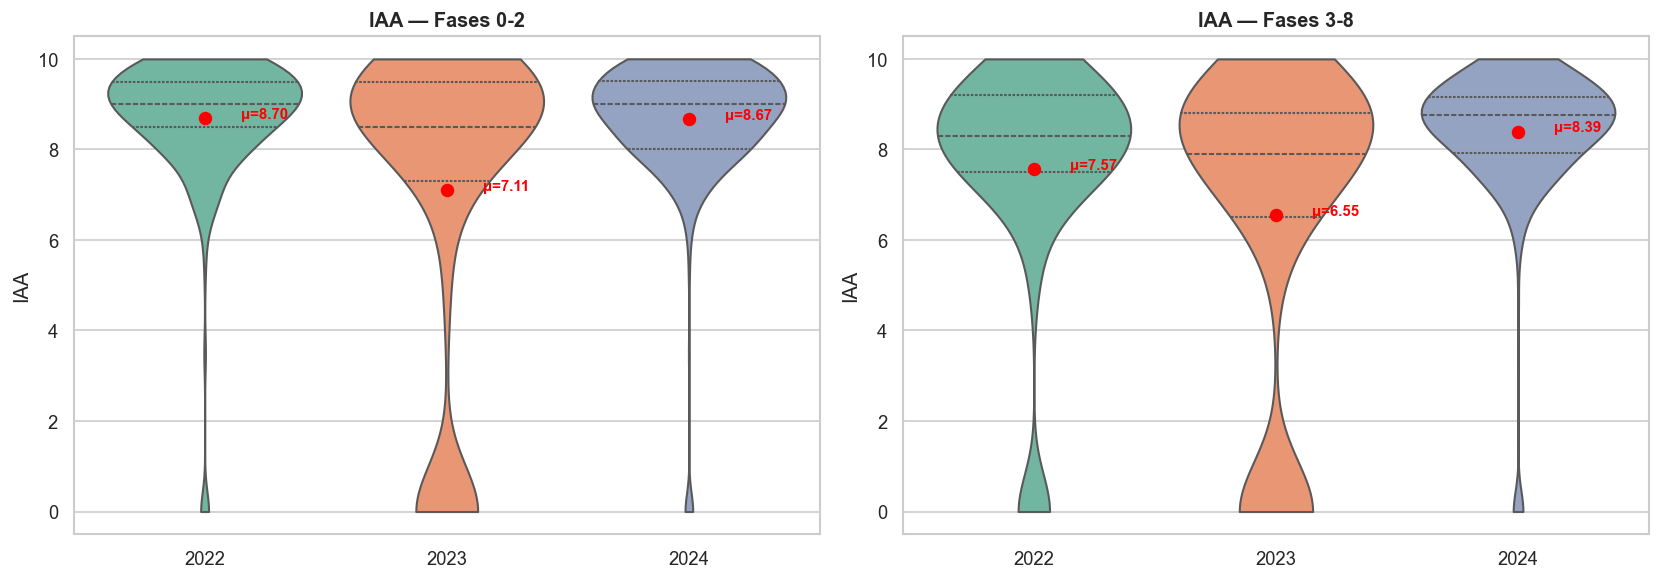

In [8]:
# Validar se a escala diferente do IAA por fase explica a anomalia de 2023
df_iaa = df[df['IAA'].notna()].copy()

# IAA médio por nível e ano
pivot_iaa = df_iaa.pivot_table(
    index='nivel', columns='ano', values='IAA', aggfunc=['mean', 'count']
)

print('=== IAA médio por nível e ano ===')
print(pivot_iaa['mean'].round(2).to_string())
print('\n=== Contagem por nível e ano ===')
print(pivot_iaa['count'].fillna(0).astype(int).to_string())

# Separar: fases 0-2 vs fases 3-8
df_iaa['grupo_fase'] = df_iaa['nivel'].apply(
    lambda x: 'Fases 0-2' if x in ['ALFA', '1', '2'] else ('Fases 3-8' if x not in ['9'] else '9')
)

resumo = df_iaa.groupby(['ano', 'grupo_fase'])['IAA'].agg(['mean', 'std', 'count']).round(2)
print('\n=== IAA por grupo de fase e ano ===')
print(resumo.to_string())

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, grupo in enumerate(['Fases 0-2', 'Fases 3-8']):
    sub = df_iaa[df_iaa['grupo_fase'] == grupo]
    sub_plot = sub.copy()
    sub_plot['ano'] = sub_plot['ano'].astype(str)
    sns.violinplot(data=sub_plot, x='ano', y='IAA', ax=axes[i],
                   palette='Set2', inner='quartile', cut=0)
    
    medias = sub_plot.groupby('ano')['IAA'].mean()
    for j, (ano, media) in enumerate(medias.items()):
        axes[i].scatter(j, media, color='red', s=50, zorder=5)
        axes[i].text(j + 0.15, media, f'μ={media:.2f}', fontsize=9, fontweight='bold', color='red')
    
    axes[i].set_title(f'IAA — {grupo}', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('IAA')

plt.tight_layout()
plt.show()

##### 💡 Insights — Validação da escala do IAA

- A hipótese de escala diferente por fase (0-2 vs 3-8) **não explica** a anomalia de 2023
- A queda é **generalizada**: ambos os grupos caíram de forma similar (~1.8 pontos) e ambos recuperaram em 2024
- O desvio padrão de 2023 é ~3.5 em ambos os grupos — mais que o dobro de 2022 e 2024
- Será que houve uma **mudança metodológica na coleta do IAA** específica de 2023?

⚠️ **Para o modelo de ML:** o IAA de 2023 deve ser tratado com cautela — a comparabilidade entre anos é questionável

### ⭐️ Insight Final



#### As percepções dos alunos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?

- **Não. A autoavaliação parece ser largamente desconectada da realidade.**

**Correlações:**
- IAA × IDA: 0.115 (muito fraca)
- IAA × IEG: 0.133 (muito fraca)
- O IAA mede uma dimensão própria — autoestima/confiança — independente do desempenho e do engajamento

**Padrão dominante: superestimação**
- ~70% dos alunos se superestimam (gap IAA-IDA > 1) em 2022 e 2024
- Gap médio = +1.55 pontos acima do desempenho real
- Na visão combinada (IAA vs IDA e IEG), 58.1% superestimam pelo menos uma dimensão e 17.4% superestimam ambas
- Apenas 25.8% são coerentes

**Nível 3 — ponto crítico recorrente:**
- Pior IDA (gargalo acadêmico, já identificado na pergunta 2 - IDA)
- Maior superestimação (gap mediano = 2.70)
- Nível mais representado entre os que superestimam ambos (IDA e IEG)
- Esses alunos se dão nota 9.06 mas tiram 4.72 no IDA — a maior distorção da base

**Anomalia de 2023:**
- IAA teve queda generalizada em todos os níveis e grupos de fase
- Não é explicada pela escala diferente (fases 0-2 vs 3-8) — a causa não foi identificada
- O IAA de 2023 deve ser tratado com cautela na modelagem

**Implicações:**
- Para a ONG: o nível 3 precisa de feedback realista — a superestimação pode estar mascarando dificuldades reais e reduzindo a busca por ajuda
- Para o modelo de ML: o IAA isolado não é bom fator, mas o **gap (IAA - IDA)** pode ser feature informativa — alunos com gap alto podem ser os que mais precisam de intervenção
- Os 9.5% que subestimam ambos merecem atenção psicossocial — possível autoestima comprometida

### Exportação da base analítica para o Streamlit


In [9]:
# EXPORTAR BASE ANALITICA DO IAA PARA O STREAMLIT
from pathlib import Path
import sys

# Usa o caminho conhecido do app a partir dos notebooks de AED.
caminho_app = Path('../../app').resolve()
if str(caminho_app) not in sys.path:
    sys.path.append(str(caminho_app))

from analise_exploratoria.analiticos.iaa import exportar_base_analitica_iaa

# Gera o parquet analitico que a aba IAA do Streamlit passa a consumir.
caminho_saida = exportar_base_analitica_iaa(df)
print(f'Base analitica do IAA exportada para: {caminho_saida}')


2026-03-22 13:04:31.780 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-22 13:04:31.781 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-22 13:04:31.781 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-22 13:04:31.782 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-22 13:04:31.782 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-22 13:04:31.783 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-22 13:04:31.784 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-22 13:04:31.784 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


Base analitica do IAA exportada para: /Users/hgirardi/Documents/Dev/pessoal/Pos_Tech_DTAT/Fase_5/Datathon/data/db/02_gold_analytics/iaa_analitico.parquet


In [10]:
# Le o artefato gerado para validar rapidamente a exportacao no proprio notebook.
iaa_parquet = pd.read_parquet(caminho_saida)


In [11]:
# Exibe as colunas finais para conferir o contrato usado pela aba do Streamlit.
iaa_parquet.columns


Index(['ano', 'RA', 'nome', 'genero', 'idade', 'ano_ingresso', 'instituicao',
       'fase', 'turma', 'nivel', 'fase_ideal', 'defasagem', 'pedra', 'INDE',
       'IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'mat', 'por', 'ing',
       'indicado_bolsa', 'atingiu_pv', 'rec_psicologia', 'pedra_20',
       'pedra_21', 'pedra_22', 'pedra_23', 'nivel_label', 'nivel_ordem',
       'gap_iaa_ida', 'gap_iaa_ieg', 'coerencia_iaa', 'coerencia_combinada'],
      dtype='object')